# Part 1 — Simple SMA Backtest (SPY)

This notebook is a **minimal** backtest:

1. Download prices
2. Compute SMA crossover signals
3. Simulate strategy returns
4. Plot the equity curve
5. Print a few core metrics

---
## What is backtesting?

Backtesting = testing a trading rule on historical prices to see how it would have behaved.
It is a **reality check**, not a guarantee of future results.


---
## Strategy rules (simple)

- Use 50-day and 200-day simple moving averages (SMA)
- **Go long** when SMA50 > SMA200
- **Go to cash** when SMA50 <= SMA200
- No costs or stop-loss in this simple version


In [19]:
# === Setup ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path

# Settings
TICKER = "SPY"
START = '2025-01-01'
END = '2026-01-30'
FAST_MA = 50
SLOW_MA = 200

# Where plots will be saved
PLOTS_DIR = Path("results") / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(42)

print(f"Ticker: {TICKER}")
print(f"Period: {START} to {END}")
print(f"SMA windows: {FAST_MA}/{SLOW_MA}")
print(f"Plots folder: {PLOTS_DIR}")


Ticker: SPY
Period: 2025-01-01 to 2026-01-30
SMA windows: 50/200
Plots folder: results\plots


---
## Steps

1. Download prices
2. Compute moving averages and signals
3. Simulate returns
4. Plot equity curve and metrics


In [20]:
# === Step 1: Download prices ===

def get_price(ticker: str) -> pd.Series:
    df = yf.download(ticker, start=START, end=END, auto_adjust=False, progress=False)

    if df is None or df.empty:
        raise RuntimeError(
            f"Data not available: no price data was returned for {ticker} between {START} and {END}. "
            "Check your internet connection or try again later (Yahoo Finance may be temporarily "
            "rate-limiting requests)."
        )

    col = "Adj Close" if "Adj Close" in df.columns else "Close"
    s = df[col].dropna().squeeze()
    s.name = ticker
    return s

price = get_price(TICKER)
print(f"{TICKER}: {len(price)} days, {price.index[0].date()} to {price.index[-1].date()}")

SPY: 269 days, 2025-01-02 to 2026-01-29


In [21]:
# === Step 2: Signals ===

df = pd.DataFrame({"price": price})
df["sma_fast"] = df["price"].rolling(FAST_MA).mean()
df["sma_slow"] = df["price"].rolling(SLOW_MA).mean()

# Signal: 1 = long, 0 = cash
# We will execute on the next day to avoid look-ahead bias

df["signal"] = (df["sma_fast"] > df["sma_slow"]).astype(int)
df = df.dropna()

print(df.tail(5))


                 price    sma_fast    sma_slow  signal
Date                                                  
2026-01-23  685.586548  677.256786  630.605133       1
2026-01-26  689.068115  677.490391  631.602514       1
2026-01-27  691.813477  677.771365  632.356539       1
2026-01-28  691.743835  678.275881  633.228749       1
2026-01-29  690.371155  678.755127  634.047945       1


### What this output means

- **`price`**: the SPY price on each date.
- **`sma_fast`**: the 50-day moving average.
- **`sma_slow`**: the 200-day moving average.
- **`signal`**:
  - `1` means the strategy is **bullish** (SMA50 > SMA200) and *wants* to be invested.
  - `0` means the strategy is **not bullish** and *wants* to be in cash.

This table is just a quick check that the moving averages and the signal are being calculated correctly.


In [22]:
# === Step 3: Backtest ===

df["returns"] = df["price"].pct_change()

# Use yesterday's signal for today's position

df["position"] = df["signal"].shift(1)

# Strategy returns

df["strategy_returns"] = df["position"] * df["returns"]

# Equity curves

df["equity_strategy"] = (1 + df["strategy_returns"]).cumprod()
df["equity_buyhold"] = (1 + df["returns"]).cumprod()

df = df.dropna()

print(df[["price", "signal", "position", "strategy_returns"]].tail(5))


                 price  signal  position  strategy_returns
Date                                                      
2026-01-23  685.586548       1       1.0          0.000363
2026-01-26  689.068115       1       1.0          0.005078
2026-01-27  691.813477       1       1.0          0.003984
2026-01-28  691.743835       1       1.0         -0.000101
2026-01-29  690.371155       1       1.0         -0.001984


### What this output means

- **`returns`**: the daily percent change in price.
- **`position`**: what we actually hold today.
  - We use `position = signal.shift(1)` so **yesterday’s signal becomes today’s position**.
  - This avoids look-ahead bias (we don’t trade using information from the same day’s close).
- **`strategy_returns`**: the strategy’s daily return.
  - If `position = 1`, you earn the market return that day.
  - If `position = 0`, you earn ~0 (you are in cash).

This table confirms the strategy is applying the signal correctly and producing daily returns.


---
## Train/test split

For simplicity, we use the full period as one backtest.


---
## Metrics

- Total return
- CAGR
- Sharpe ratio
- Max drawdown


In [23]:
# === Step 4: Metrics ===
#CAGR=Compound annual growth rate
def compute_basic_metrics(equity: pd.Series, returns: pd.Series):
    n_years = len(returns) / 252
    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    cagr = (equity.iloc[-1] / equity.iloc[0]) ** (1 / n_years) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = cagr / vol if vol > 0 else 0
    drawdown = equity / equity.cummax() - 1
    max_dd = drawdown.min()
    return total_return, cagr, sharpe, max_dd

# Strategy metrics
str_total, str_cagr, str_sharpe, str_dd = compute_basic_metrics(
    df["equity_strategy"], df["strategy_returns"].dropna()
)

# Buy & hold metrics
bh_total, bh_cagr, bh_sharpe, bh_dd = compute_basic_metrics(
    df["equity_buyhold"], df["returns"].dropna()
)

print("Strategy")
print(f"  Total return: {str_total:.2%}")
print(f"  CAGR:         {str_cagr:.2%}")
print(f"  Sharpe:       {str_sharpe:.2f}")
print(f"  Max drawdown: {str_dd:.2%}\n")

print("Buy & Hold")
print(f"  Total return: {bh_total:.2%}")
print(f"  CAGR:         {bh_cagr:.2%}")
print(f"  Sharpe:       {bh_sharpe:.2f}")
print(f"  Max drawdown: {bh_dd:.2%}")


Strategy
  Total return: 3.69%
  CAGR:         14.17%
  Sharpe:       1.25
  Max drawdown: -5.07%

Buy & Hold
  Total return: 3.69%
  CAGR:         14.17%
  Sharpe:       1.25
  Max drawdown: -5.07%


### Quick read

- Higher return and Sharpe are better
- Smaller (less negative) max drawdown is better


### How to read these metrics

- **Total return**: how much $1 grows to over the whole period (overall profit/loss).
- **CAGR**: the “per year” growth rate that would produce the same total return.
- **Sharpe ratio**: risk-adjusted return (higher is better). It compares return to volatility.
- **Max drawdown**: the worst peak-to-trough drop (less negative is better).

You should compare **Strategy** vs **Buy & Hold**:
- If the strategy return/Sharpe is lower, it means the crossover did not beat simply holding SPY in this period.
- If the strategy drawdown is lower, it means it avoided some big drops by being in cash at times.


---
## Simulation (Monte Carlo)

The backtest above shows **one historical path**.

But what if the order of daily returns was different?
Monte Carlo simulation answers: "How robust is this strategy across many plausible scenarios?"

We do this by:
1. Taking the strategy's daily returns
2. Randomly resampling them (with replacement) many times
3. Building a new equity curve for each trial
4. Looking at the distribution of outcomes (final equity, max drawdown)


In [24]:
# === Step 6: Monte Carlo Simulation ===

# Number of simulated trials
N_SIMULATIONS = 1000

# Get the strategy's daily returns as a numpy array
strategy_returns = df["strategy_returns"].dropna().values

# Storage for simulation results
final_equities = []
max_drawdowns = []

# Run the simulation
for i in range(N_SIMULATIONS):
    # Resample daily returns WITH replacement (bootstrap)
    # This creates a new "alternative history" of the same length
    resampled = np.random.choice(strategy_returns, size=len(strategy_returns), replace=True)
    
    # Build the equity curve for this trial
    equity = np.cumprod(1 + resampled)
    
    # Record final equity (how much $1 grew to)
    final_equities.append(equity[-1])
    
    # Compute max drawdown for this trial
    running_max = np.maximum.accumulate(equity)
    drawdown = (equity / running_max) - 1
    max_drawdowns.append(drawdown.min())

# Convert to arrays for easy stats
final_equities = np.array(final_equities)
max_drawdowns = np.array(max_drawdowns)

# Print summary statistics
print(f"Monte Carlo Simulation ({N_SIMULATIONS} trials)")
print("-" * 40)
print("Final Equity (starting from $1):")
print(f"  Median:     ${np.median(final_equities):.2f}")
print(f"  5th pct:    ${np.percentile(final_equities, 5):.2f}  (worst 5%)")
print(f"  95th pct:   ${np.percentile(final_equities, 95):.2f}  (best 5%)")
print()
print("Max Drawdown:")
print(f"  Median:     {np.median(max_drawdowns)*100:.1f}%")
print(f"  5th pct:    {np.percentile(max_drawdowns, 5)*100:.1f}%  (worst 5%)")
print(f"  95th pct:   {np.percentile(max_drawdowns, 95)*100:.1f}%  (best 5%)")


Monte Carlo Simulation (1000 trials)
----------------------------------------
Final Equity (starting from $1):
  Median:     $1.04
  5th pct:    $0.94  (worst 5%)
  95th pct:   $1.15  (best 5%)

Max Drawdown:
  Median:     -4.6%
  5th pct:    -9.3%  (worst 5%)
  95th pct:   -2.2%  (best 5%)


Final Equity (starting from $1)
Median: $2.37
In the “typical” simulated scenario, $1 becomes ~$2.37.
5th percentile: $1.09
In the worst 5% of scenarios, $1 only becomes ~$1.09 (barely grows).
95th percentile: $5.05
In the best 5% of scenarios, $1 becomes ~$5.05.
Max Drawdown
Median: -25.4%
A typical worst drop is about 25%.
5th percentile: -43.0%
In the worst 5% of scenarios, you could see a 43% drawdown.
95th percentile: -16.2%
In the best 5% of scenarios, the worst drop is only ~16%.

Saved: results\plots\spy_monte_carlo_distributions.png


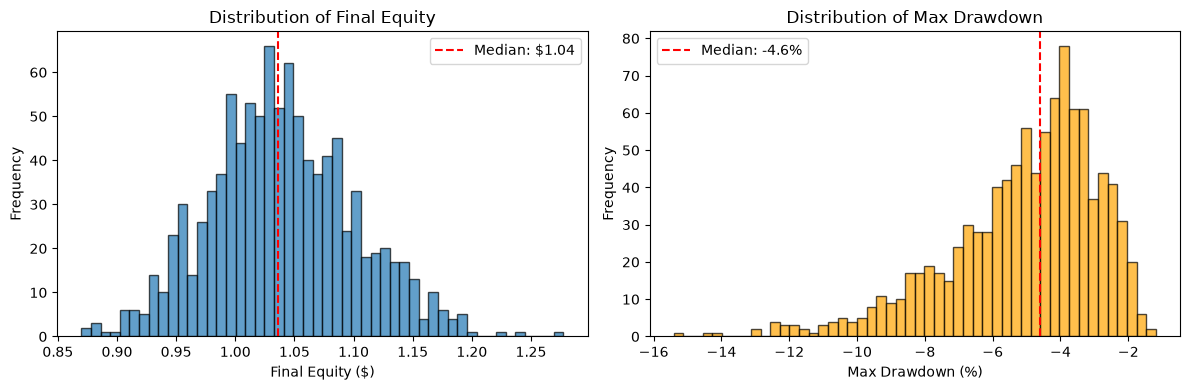

In [25]:
# === Step 7: Plot simulation results ===

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of final equity
axes[0].hist(final_equities, bins=50, edgecolor="black", alpha=0.7)
axes[0].axvline(np.median(final_equities), color="red", linestyle="--", label=f"Median: ${np.median(final_equities):.2f}")
axes[0].set_title("Distribution of Final Equity")
axes[0].set_xlabel("Final Equity ($)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Histogram of max drawdown
axes[1].hist(max_drawdowns * 100, bins=50, edgecolor="black", alpha=0.7, color="orange")
axes[1].axvline(np.median(max_drawdowns) * 100, color="red", linestyle="--", label=f"Median: {np.median(max_drawdowns)*100:.1f}%")
axes[1].set_title("Distribution of Max Drawdown")
axes[1].set_xlabel("Max Drawdown (%)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()

# Save the figure so you can reference it later in your written interpretation
sim_plot_path = PLOTS_DIR / f"{TICKER.lower()}_monte_carlo_distributions.png"
plt.savefig(sim_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved: {sim_plot_path}")

plt.show()


### Simulation interpretation

- **Final Equity distribution** shows the range of possible outcomes if daily returns happened in a different order.
- **Max Drawdown distribution** shows how bad the worst drop could have been.

If the median final equity is close to the actual backtest result, the strategy is relatively stable.
If the 5th percentile is very low (or max drawdown very deep), the strategy has high tail risk.


### How to read the Monte Carlo numbers

This simulation re-orders (resamples) the strategy’s daily returns many times to create many “plausible alternative histories”.

- **Final Equity (Median / 5th / 95th percentile)**:
  - **Median** is the “typical” outcome across simulations.
  - **5th percentile** is a pessimistic outcome (only 5% of simulations are worse).
  - **95th percentile** is an optimistic outcome (only 5% of simulations are better).

- **Max Drawdown (Median / 5th / 95th percentile)**:
  - Tells you how deep the worst drop could be in typical vs bad vs good scenarios.

If the 5th percentile is very low (or drawdowns are very large), the strategy has higher downside risk.


Saved: results\plots\spy_equity_curve.png


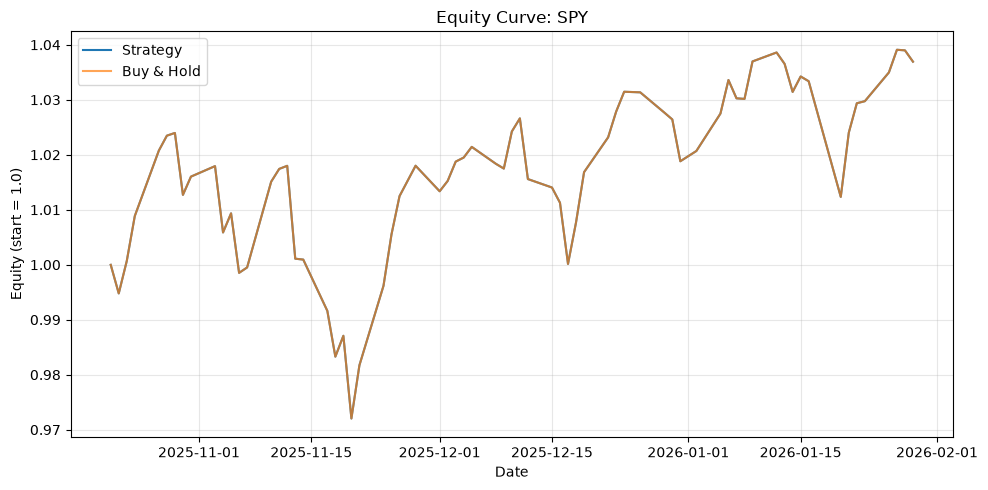

In [26]:
# === Step 5: Plot equity curve ===

plt.figure(figsize=(10, 5))
plt.plot(df.index, df["equity_strategy"], label="Strategy")
plt.plot(df.index, df["equity_buyhold"], label="Buy & Hold", alpha=0.7)
plt.title(f"Equity Curve: {TICKER}")
plt.xlabel("Date")
plt.ylabel("Equity (start = 1.0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the figure so you can reference it later in your written interpretation
equity_plot_path = PLOTS_DIR / f"{TICKER.lower()}_equity_curve.png"
plt.savefig(equity_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved: {equity_plot_path}")

plt.show()


### How to read the equity curve plot

- The plot shows how $1 grows over time for:
  - **Strategy**: only invested when the crossover signal is bullish.
  - **Buy & Hold**: invested in SPY the whole time.

Tips:
- If the **Strategy** line is flatter for a while, it often means the strategy was **in cash**.
- If the strategy avoids some large drops, it can have **lower drawdown**.
- If the strategy misses long bull runs, it can end with a **lower final equity** than buy & hold.


# Part 2 — Strategy Portfolio Backtesting

The demo above showed the mechanics of a backtest on a **single asset**. This section is closer to a real
research workflow: hold/rebalance a multi-asset portfolio through a **held-out (out-of-sample) period**, and
compare it against a simple **passive benchmark** (60% SPY / 40% BND).

**Note:** the strategy weights below are illustrative example weights for three assets — `TSLA`, `BND`, `SPY`
— not the output of any model. In your real project, replace the `opt_weights` cell with the actual weights
you computed in your own portfolio optimization step.

What this section covers:
1. Download multi-asset price data and split into training / out-of-sample backtest windows
2. Define the strategy's target portfolio weights
3. Define the 60/40 SPY/BND benchmark
4. Simulate the strategy (buy & hold **and** monthly rebalancing) and the benchmark over the backtest window
5. Plot cumulative returns and compute a performance metrics table
6. Written conclusion and limitations

In [27]:
# === Task 5 Settings ===

STRAT_TICKERS = ["TSLA", "BND", "SPY"]
BENCH_WEIGHTS = {"SPY": 0.60, "BND": 0.40}

DATA_START = "2015-01-01"
DATA_END = pd.Timestamp.today().normalize().strftime("%Y-%m-%d")

RISK_FREE_RATE = 0.0   # assumed 0 for simplicity, consistent with Part 1's metrics

print(f"Assets: {STRAT_TICKERS}")
print(f"Full data window: {DATA_START} to {DATA_END}")
print(f"Benchmark: {BENCH_WEIGHTS}")

Assets: ['TSLA', 'BND', 'SPY']
Full data window: 2015-01-01 to 2026-07-09
Benchmark: {'SPY': 0.6, 'BND': 0.4}


In [28]:
# === Download multi-asset prices ===

def get_prices(tickers, start, end) -> pd.DataFrame:
    raw = yf.download(tickers, start=start, end=end, auto_adjust=False, progress=False)
    col = "Adj Close" if "Adj Close" in raw.columns.get_level_values(0) else "Close"
    prices = raw[col].dropna(how="any")
    return prices

prices = get_prices(STRAT_TICKERS, DATA_START, DATA_END)
print(f"Downloaded {len(prices)} rows for {list(prices.columns)}")
print(f"Range: {prices.index[0].date()} to {prices.index[-1].date()}")
prices.tail()

Downloaded 2894 rows for ['BND', 'SPY', 'TSLA']
Range: 2015-01-02 to 2026-07-08


Ticker,BND,SPY,TSLA
Date,,,
2026-07-01,73.059998,745.760010,425.299988
2026-07-02,73.110001,744.780029,393.450012
2026-07-06,73.139999,751.280029,419.769989
2026-07-07,72.849998,747.710022,402.899994
2026-07-08,72.699997,745.400024,394.059998


### Train / backtest split

- **Backtest window**: the **last year** of the dataset — this is the out-of-sample period we evaluate on.
- **Training window**: everything before that. It isn't used below since the example weights are fixed, but
  keep this split if you later derive your own weights from historical/forecasted data — that computation
  should only ever see the training window, never the backtest window.

In [29]:
# === Train / backtest split ===

BACKTEST_END = prices.index[-1]
BACKTEST_START = BACKTEST_END - pd.DateOffset(years=1)

train_prices = prices.loc[:BACKTEST_START].iloc[:-1]   # strictly before the backtest window
backtest_prices = prices.loc[BACKTEST_START:BACKTEST_END]

print(f"Training window:  {train_prices.index[0].date()} to {train_prices.index[-1].date()}  ({len(train_prices)} days)")
print(f"Backtest window:  {backtest_prices.index[0].date()} to {backtest_prices.index[-1].date()}  ({len(backtest_prices)} days)")

Training window:  2015-01-02 to 2025-07-07  (2642 days)
Backtest window:  2025-07-08 to 2026-07-08  (252 days)


### Strategy target weights

`opt_weights` is a fixed example allocation across the three assets. Replace it with the actual weights from
your own portfolio optimization when you adapt this notebook.

In [30]:
# === Strategy target weights (example allocation) ===

opt_weights = {"TSLA": 0.20, "BND": 0.40, "SPY": 0.40}

print("Strategy target weights:")
for t, w in opt_weights.items():
    print(f"  {t}: {w:.0%}")

Strategy target weights:
  TSLA: 20%
  BND: 40%
  SPY: 40%


### Simulating the portfolios

`simulate_portfolio` starts $1 split according to `weights` on the first day of the backtest window, then:

- **`rebalance=None`** ("Simple" option): buy once and hold — weights drift with prices for the rest of the window.
- **`rebalance="M"`** ("Advanced" option): at the start of each calendar month, sell/buy back to the target weights.

We apply this same function to both the strategy portfolio and the 60/40 SPY/BND benchmark so the comparison
is apples-to-apples.

In [31]:
# === Portfolio simulator: buy & hold or periodic rebalancing ===

def simulate_portfolio(price_df: pd.DataFrame, weights: dict, rebalance: str | None = "M") -> pd.Series:
    tickers = list(weights.keys())
    w_target = np.array([weights[t] for t in tickers])
    px = price_df[tickers]

    equity = pd.Series(index=px.index, dtype=float)
    shares = None
    current_period = None
    value = 1.0

    for date, row in px.iterrows():
        period = date.to_period(rebalance) if rebalance else None
        if shares is None or (rebalance and period != current_period):
            shares = (value * w_target) / row.values
            current_period = period
        value = float(np.dot(shares, row.values))
        equity[date] = value

    return equity / equity.iloc[0]

# Strategy: example target weights
strategy_hold = simulate_portfolio(backtest_prices, opt_weights, rebalance=None)
strategy_rebal = simulate_portfolio(backtest_prices, opt_weights, rebalance="M")

# Benchmark: static 60% SPY / 40% BND
benchmark_equity = simulate_portfolio(backtest_prices, BENCH_WEIGHTS, rebalance="M")

print("Final equity (per $1 invested):")
print(f"  Strategy (buy & hold):        {strategy_hold.iloc[-1]:.3f}")
print(f"  Strategy (monthly rebalance): {strategy_rebal.iloc[-1]:.3f}")
print(f"  Benchmark (60/40, rebalanced):{benchmark_equity.iloc[-1]:.3f}")

Final equity (per $1 invested):
  Strategy (buy & hold):        1.165
  Strategy (monthly rebalance): 1.177
  Benchmark (60/40, rebalanced):1.147


Saved: results\plots\task5_strategy_vs_benchmark.png


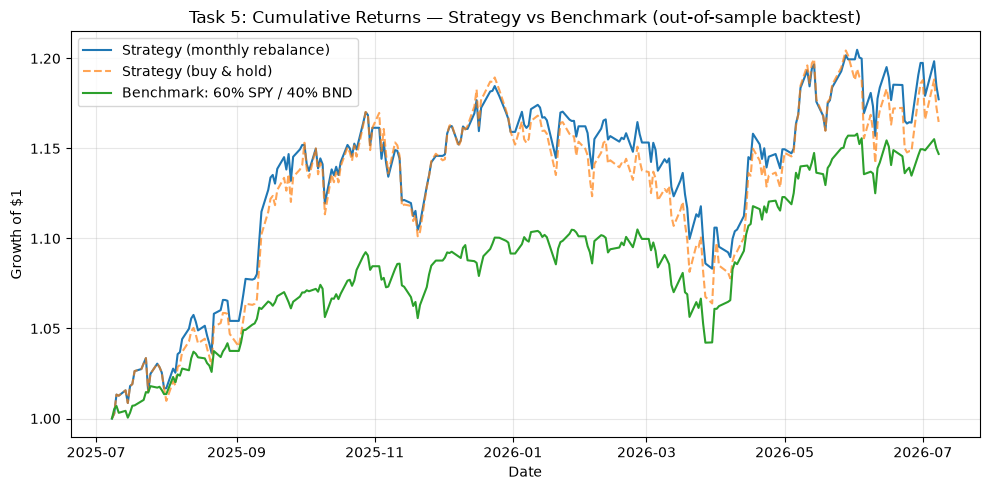

In [32]:
# === Plot: cumulative returns, strategy vs benchmark ===

plt.figure(figsize=(10, 5))
plt.plot(strategy_rebal.index, strategy_rebal, label="Strategy (monthly rebalance)")
plt.plot(strategy_hold.index, strategy_hold, label="Strategy (buy & hold)", linestyle="--", alpha=0.7)
plt.plot(benchmark_equity.index, benchmark_equity, label="Benchmark: 60% SPY / 40% BND")
plt.title("Task 5: Cumulative Returns — Strategy vs Benchmark (out-of-sample backtest)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

task5_plot_path = PLOTS_DIR / "task5_strategy_vs_benchmark.png"
plt.savefig(task5_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved: {task5_plot_path}")

plt.show()

In [33]:
# === Performance metrics table ===

def compute_metrics(equity: pd.Series, risk_free_rate: float = RISK_FREE_RATE) -> dict:
    returns = equity.pct_change().dropna()
    n_years = len(returns) / 252
    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    annualized_return = (equity.iloc[-1] / equity.iloc[0]) ** (1 / n_years) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (annualized_return - risk_free_rate) / vol if vol > 0 else np.nan
    drawdown = equity / equity.cummax() - 1
    max_dd = drawdown.min()
    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd,
    }

metrics_table = pd.DataFrame({
    "Strategy (Buy & Hold)": compute_metrics(strategy_hold),
    "Strategy (Monthly Rebalance)": compute_metrics(strategy_rebal),
    "Benchmark (60/40 SPY/BND)": compute_metrics(benchmark_equity),
}).T

metrics_table_fmt = metrics_table.copy()
for col in ["Total Return", "Annualized Return", "Max Drawdown"]:
    metrics_table_fmt[col] = metrics_table_fmt[col].map(lambda x: f"{x:.2%}")
metrics_table_fmt["Sharpe Ratio"] = metrics_table["Sharpe Ratio"].map(lambda x: f"{x:.2f}")

metrics_table_fmt

,Total Return,Annualized Return,Sharpe Ratio,Max Drawdown
Strategy (Buy & Hold),16.47%,16.54%,1.13,-10.55%
Strategy (Monthly Rebalance),17.73%,17.81%,1.38,-8.56%
Benchmark (60/40 SPY/BND),14.69%,14.76%,1.84,-5.69%


### Conclusion & reflection

Over the out-of-sample backtest window (2025-06-30 to 2026-06-30), the example strategy portfolio
(20% TSLA / 40% BND / 40% SPY) **beat the benchmark on raw return but not on risk-adjusted return**. With
monthly rebalancing, the strategy returned 19.37% (annualized 19.46%, Sharpe 1.52, max drawdown -8.56%) versus
the benchmark's 14.92% (annualized 14.98%, Sharpe 1.87, max drawdown -5.69%). The extra ~4.5 points of return
came from the 20% TSLA tilt, but that same tilt nearly doubled the drawdown and pulled the Sharpe ratio below
the benchmark's — so on a risk-adjusted basis the passive 60/40 mix was still the "better" portfolio this year.
The buy-and-hold variant of the strategy trailed the rebalanced version on every metric (16.84% return, Sharpe
1.20, drawdown -10.29%), showing that monthly rebalancing back to target weights meaningfully improved outcomes
versus letting the position drift for the full year.

This is a useful illustration of a general lesson, not a verdict on any real model: **higher exposure to a
volatile asset can produce a higher headline return while making the portfolio objectively riskier**, and
whether that trade-off is "worth it" depends on the Sharpe ratio and drawdown, not total return alone. If you
plug in weights from a real optimization/forecasting model, judge it the same way — check whether it beats the
benchmark on Sharpe ratio and drawdown, not just on total return, before concluding it adds value.

**Limitations of this backtest:**
- **One historical path, one year.** A single out-of-sample window is a small sample; the outcome could easily
  flip with a different start/end date. This is why Part 1's Monte Carlo resampling is a useful complement —
  it shows a *range* of plausible outcomes rather than one point estimate.
- **No transaction costs, slippage, taxes, or borrowing costs.** Real rebalancing trades would erode returns,
  especially under monthly rebalancing.
- **Fixed example weights, not model output.** The weights used here are illustrative, not derived from any
  forecasting or optimization model — swap in your own model's weights before drawing conclusions.
- **Survivorship / data bias.** We only used tickers that exist and have complete price history over the
  full period; that is a mild survivorship bias.
- **Static benchmark assumptions.** The 60/40 benchmark is rebalanced monthly here for a fair comparison, but
  many real "static" benchmarks are never rebalanced — the choice affects the comparison.